Phase 1

In [ ]:
import pandas as pd
import numpy as np
import ssl
from sklearn.preprocessing import LabelEncoder

# Bypass SSL verification for the data download
ssl._create_default_https_context = ssl._create_unverified_context

data_url = "https://data.lacity.org/api/views/2nrs-mtv8/rows.csv?accessType=DOWNLOAD"

print("Fetching live data from LA Open Data Portal... SSL bypass active.")
raw_df = pd.read_csv(data_url, low_memory=False)

Fetching live data from LA Open Data Portal... SSL bypass active.


In [ ]:
raw_df.head()
raw_df.info()
raw_df.describe()
raw_df.count()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004894 entries, 0 to 1004893
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   DR_NO           1004894 non-null  int64  
 1   Date Rptd       1004894 non-null  object 
 2   DATE OCC        1004894 non-null  object 
 3   TIME OCC        1004894 non-null  int64  
 4   AREA            1004894 non-null  int64  
 5   AREA NAME       1004894 non-null  object 
 6   Rpt Dist No     1004894 non-null  int64  
 7   Part 1-2        1004894 non-null  int64  
 8   Crm Cd          1004894 non-null  int64  
 9   Crm Cd Desc     1004894 non-null  object 
 10  Mocodes         853296 non-null   object 
 11  Vict Age        1004894 non-null  int64  
 12  Vict Sex        860263 non-null   object 
 13  Vict Descent    860251 non-null   object 
 14  Premis Cd       1004878 non-null  float64
 15  Premis Desc     1004306 non-null  object 
 16  Weapon Used Cd  327216 non-null   fl

DR_NO             1004894
Date Rptd         1004894
DATE OCC          1004894
TIME OCC          1004894
AREA              1004894
AREA NAME         1004894
Rpt Dist No       1004894
Part 1-2          1004894
Crm Cd            1004894
Crm Cd Desc       1004894
Mocodes            853296
Vict Age          1004894
Vict Sex           860263
Vict Descent       860251
Premis Cd         1004878
Premis Desc       1004306
Weapon Used Cd     327216
Weapon Desc        327216
Status            1004893
Status Desc       1004894
Crm Cd 1          1004883
Crm Cd 2            69154
Crm Cd 3             2314
Crm Cd 4               64
LOCATION          1004894
Cross Street       154228
LAT               1004894
LON               1004894
dtype: int64

In [ ]:
import pandas as pd
import numpy as np

# df = pd.read_csv('data/Crime_Data_from_2020_to_Present.csv')

def clean_and_impute_full(df):
    # 1. Temporal Conversion
    raw_df['DATE OCC'] = pd.to_datetime(df['DATE OCC'], errors='coerce')
    
    # 2. Impute Missing Victim Age (Median)
    median_age = df[df['Vict Age'] > 0]['Vict Age'].median()
    raw_df['Vict Age'] = df['Vict Age'].fillna(median_age)
    df.loc[df['Vict Age'] <= 0, 'Vict Age'] = median_age
    
    # 3. Handle Missing Coordinates (Flagging instead of deleting)
    raw_df['is_gps_missing'] = ((raw_df['LAT'] == 0) | (raw_df['LON'] == 0) | (raw_df['LAT'].isna())).astype(int)
    # Filling missing GPS with LA City Center to prevent clustering errors
    raw_df['LAT'] = raw_df['LAT'].replace(0, 34.0522).fillna(34.0522)
    raw_df['LON'] = raw_df['LON'].replace(0, -118.2437).fillna(-118.2437)

    # 4. Feature 1 & 2: Time Buckets & Weekend Flag
    raw_df['Hour'] = (raw_df['TIME OCC'] // 100).fillna(0).astype(int)
    def time_bucket(h):
        if 0 <= h <= 5: return "Night"
        elif 6 <= h <= 11: return "Morning"
        elif 12 <= h <= 17: return "Afternoon"
        else: return "Evening"
    raw_df['time_bucket'] = raw_df['Hour'].apply(time_bucket)
    raw_df['is_weekend'] = raw_df['DATE OCC'].dt.dayofweek.isin([5, 6]).astype(int)

    # 5. Feature 3: Violent Crimes vs Property (Mapping Part 1-2)
    if "Part 1-2" in raw_df.columns:
        raw_df["crime_category"] = raw_df["Part 1-2"].map({1: "Violent", 2: "Property"}).fillna("Unknown")
        raw_df["is_violent"] = raw_df["Part 1-2"].map({1: 1, 2: 0}).fillna(0).astype(int)

    # 6. Fill all other categoricals with 'UNKNOWN' to keep rows
    categorical_cols = raw_df.select_dtypes(include=['object']).columns
    raw_df[categorical_cols] = raw_df[categorical_cols].fillna('UNKNOWN')
    
    return raw_df

# Run Cleaning
df = clean_and_impute_full(raw_df)

# Save the full dataset
output_path = 'data/cleaned_crime_data_full.csv'
df.to_csv(output_path, index=False)

print(f"Phase 1 Complete. Dataset Saved to: {output_path}")
print(f"Total Rows Preserved: {len(df)}")
print(f"Columns Available: {len(df.columns)}")

C:\Users\aryam\AppData\Local\Temp\ipykernel_16648\3832319080.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DATE OCC'] = pd.to_datetime(df['DATE OCC'], errors='coerce')


Phase 1 Complete. Dataset Saved to: data/cleaned_crime_data_full.csv
Total Rows Preserved: 1004894
Columns Available: 34


In [ ]:
df.head()
df.info()
df.describe()
df.count()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004894 entries, 0 to 1004893
Data columns (total 34 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   DR_NO           1004894 non-null  int64         
 1   Date Rptd       1004894 non-null  object        
 2   DATE OCC        1004894 non-null  datetime64[ns]
 3   TIME OCC        1004894 non-null  int64         
 4   AREA            1004894 non-null  int64         
 5   AREA NAME       1004894 non-null  object        
 6   Rpt Dist No     1004894 non-null  int64         
 7   Part 1-2        1004894 non-null  int64         
 8   Crm Cd          1004894 non-null  int64         
 9   Crm Cd Desc     1004894 non-null  object        
 10  Mocodes         1004894 non-null  object        
 11  Vict Age        1004894 non-null  int64         
 12  Vict Sex        1004894 non-null  object        
 13  Vict Descent    1004894 non-null  object        
 14  Premis Cd       10

DR_NO             1004894
Date Rptd         1004894
DATE OCC          1004894
TIME OCC          1004894
AREA              1004894
AREA NAME         1004894
Rpt Dist No       1004894
Part 1-2          1004894
Crm Cd            1004894
Crm Cd Desc       1004894
Mocodes           1004894
Vict Age          1004894
Vict Sex          1004894
Vict Descent      1004894
Premis Cd         1004878
Premis Desc       1004894
Weapon Used Cd     327216
Weapon Desc       1004894
Status            1004894
Status Desc       1004894
Crm Cd 1          1004883
Crm Cd 2            69154
Crm Cd 3             2314
Crm Cd 4               64
LOCATION          1004894
Cross Street      1004894
LAT               1004894
LON               1004894
is_gps_missing    1004894
Hour              1004894
time_bucket       1004894
is_weekend        1004894
crime_category    1004894
is_violent        1004894
dtype: int64

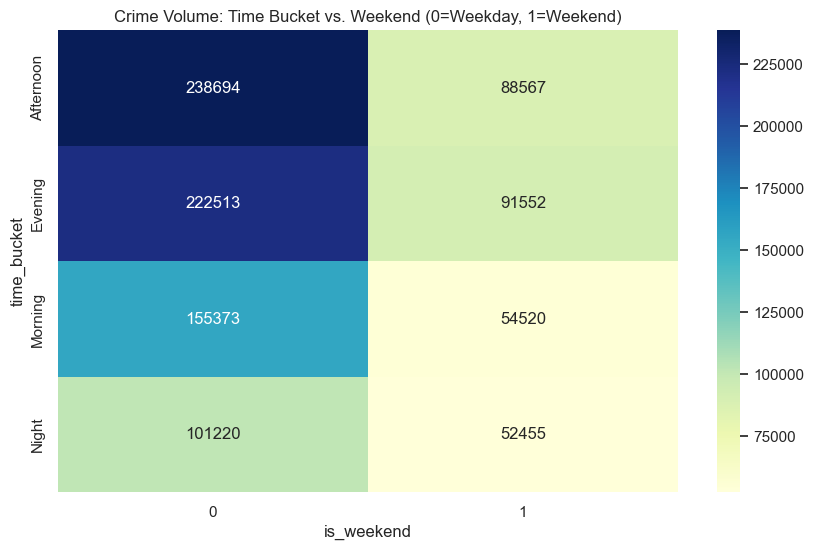

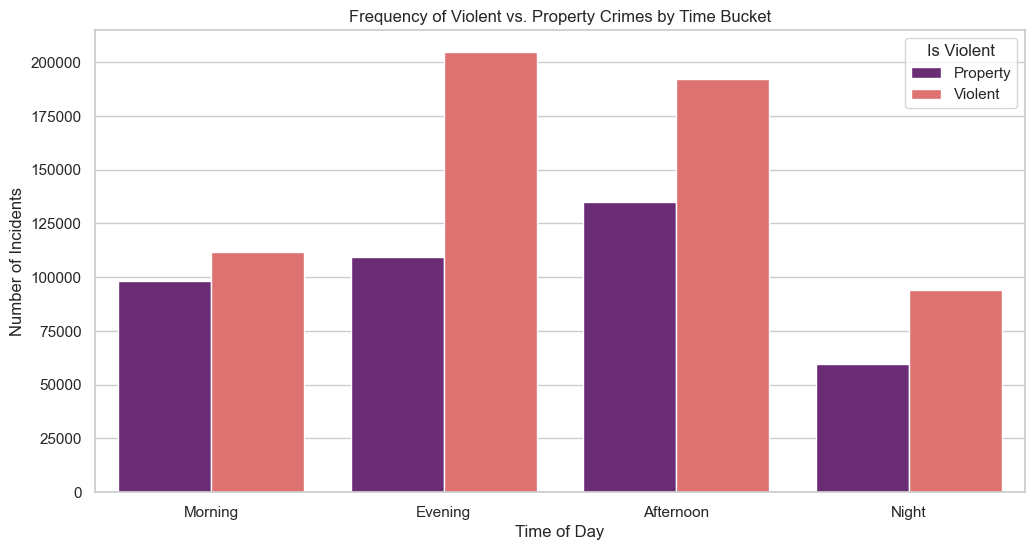

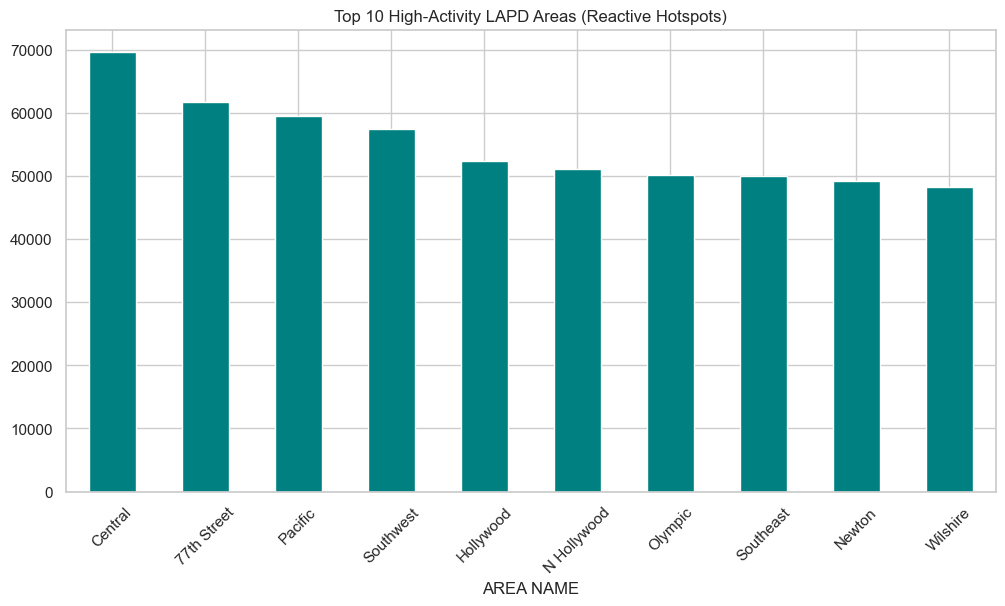

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for a professional capstone look
plt.style.use('seaborn-v0_8-muted')
sns.set_theme(style="whitegrid")

# 1. Temporal Heatmap: Proving the "Time Bucket" and "Weekend" relevance
pivot_table = df.pivot_table(
    index='time_bucket', 
    columns='is_weekend', 
    values='DR_NO', 
    aggfunc='count'
)
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt="d", cmap="YlGnBu")
plt.title('Crime Volume: Time Bucket vs. Weekend (0=Weekday, 1=Weekend)')
plt.show()

# 2. Severity Analysis: Proving the "Is_Violent" relevance
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='time_bucket', hue='is_violent', palette='magma')
plt.title('Frequency of Violent vs. Property Crimes by Time Bucket')
plt.xlabel('Time of Day')
plt.ylabel('Number of Incidents')
plt.legend(title='Is Violent', labels=['Property', 'Violent'])
plt.show()

# 3. Spatial Concentration: Top 10 High-Activity Areas
plt.figure(figsize=(12, 6))
df['AREA NAME'].value_counts().head(10).plot(kind='bar', color='teal')
plt.title('Top 10 High-Activity LAPD Areas (Reactive Hotspots)')
plt.xticks(rotation=45)
plt.show()

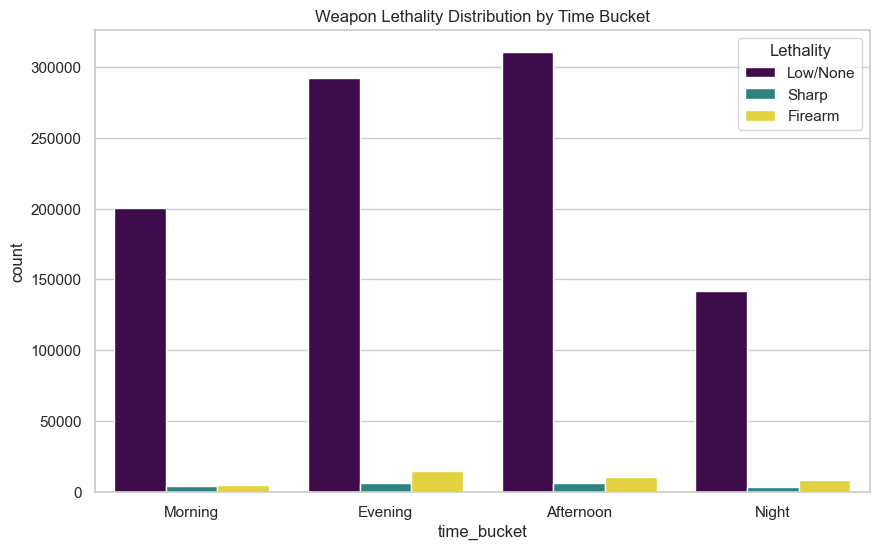

In [ ]:
def categorize_weapons(desc):
    desc = str(desc).upper()
    if 'FIREARM' in desc or 'GUN' in desc or 'PISTOL' in desc:
        return 2 # High Lethality
    elif 'KNIFE' in desc or 'SHARP' in desc or 'CUTTING' in desc:
        return 1 # Medium Lethality
    else:
        return 0 # Low/No Weapon

df['weapon_lethality'] = df['Weapon Desc'].apply(categorize_weapons)

# Quick EDA for the report
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='time_bucket', hue='weapon_lethality', palette='viridis')
plt.title('Weapon Lethality Distribution by Time Bucket')
plt.legend(title='Lethality', labels=['Low/None', 'Sharp', 'Firearm'])
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

# Selecting the Proactive Features
features = ['LAT', 'LON', 'is_weekend', 'is_violent', 'weapon_lethality']

# We need to encode the Time Bucket numbers since they are strings
df['time_encoded'] = df['time_bucket'].map({
    'Morning': 0, 'Afternoon': 1, 'Evening': 2, 'Night': 3
})
features.append('time_encoded')

# Scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[features])

print("Features scaled and ready for Phase 2: Clustering.")

Features scaled and ready for Phase 2: Clustering.


Phase 2

Calculating Optimal Proactive Zones across 6 dimensions...
Mathematical Optimal Clusters for LAPD Proactive Dispatch: 5


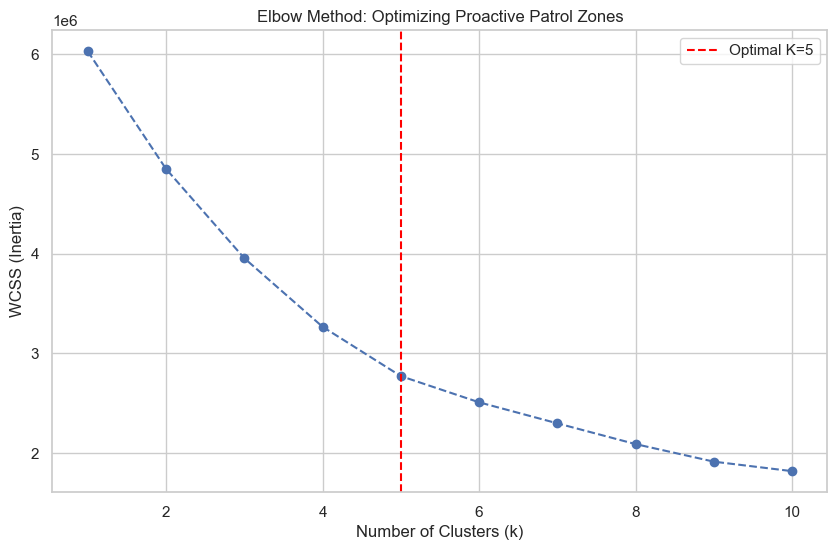

In [18]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
import matplotlib.pyplot as plt

# Using the features we standardized: LAT, LON, is_weekend, is_violent, weapon_lethality, time_encoded
wcss = []
k_range = range(1, 11)

print("Calculating Optimal Proactive Zones across 6 dimensions...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Automatically detect the elbow
kl = KneeLocator(k_range, wcss, curve="convex", direction="decreasing")
optimal_k = kl.elbow

print(f"Mathematical Optimal Clusters for LAPD Proactive Dispatch: {optimal_k}")

# Visualization of the Elbow
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal K={optimal_k}')
plt.title('Elbow Method: Optimizing Proactive Patrol Zones')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.legend()
plt.show()

In [19]:
# Applying the optimal K
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
df['proactive_cluster'] = kmeans_final.fit_predict(scaled_features)

# Let's see the "Risk Profile" of each cluster
cluster_summary = df.groupby('proactive_cluster').agg({
    'is_violent': 'mean',
    'weapon_lethality': 'mean',
    'is_weekend': 'mean',
    'time_encoded': 'median'
}).reset_index()

print("Proactive Cluster Profiles (Mean Values):")
print(cluster_summary)

Proactive Cluster Profiles (Mean Values):
   proactive_cluster  is_violent  weapon_lethality  is_weekend  time_encoded
0                  0    0.000000          0.001356    0.000000           1.0
1                  1    1.000000          0.000000    0.000000           1.0
2                  2    0.933900          1.696500    0.325670           2.0
3                  3    0.586603          0.000658    1.000000           2.0
4                  4    0.583663          0.012743    0.232701           1.0


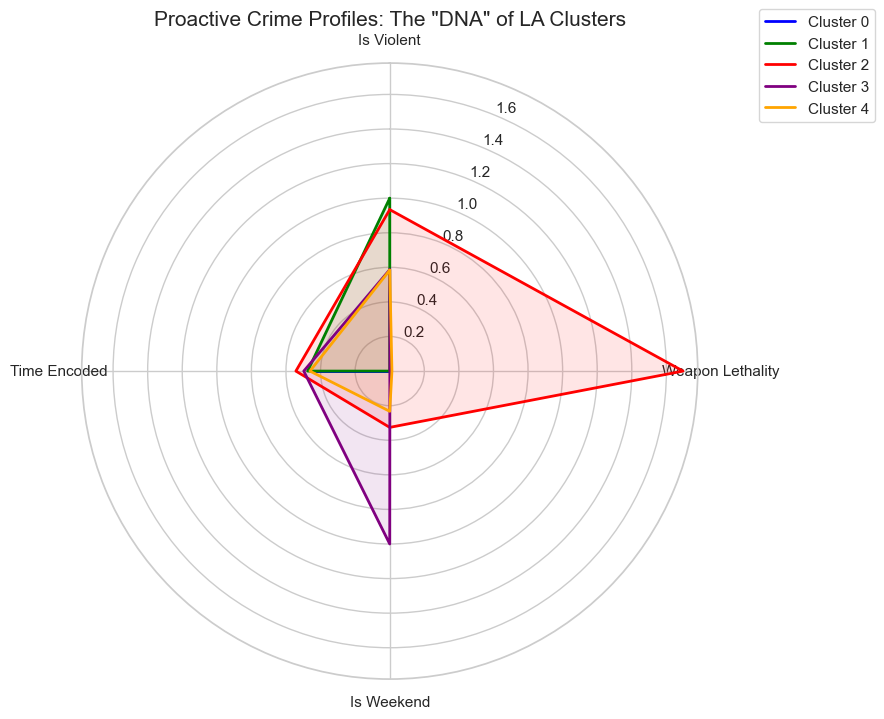

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare the data from your mean values
labels = ['Is Violent', 'Weapon Lethality', 'Is Weekend', 'Time Encoded']
num_vars = len(labels)

# Extracting the means for the 5 clusters
cluster_means = df.groupby('proactive_cluster')[['is_violent', 'weapon_lethality', 'is_weekend', 'time_encoded']].mean().values

# Normalizing time_encoded for the plot (0-1 scale)
cluster_means[:, 3] = cluster_means[:, 3] / 3.0

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Close the circle

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colors = ['blue', 'green', 'red', 'purple', 'orange']
for i in range(len(cluster_means)):
    values = cluster_means[i].tolist()
    values += values[:1]
    ax.plot(angles, values, color=colors[i], linewidth=2, label=f'Cluster {i}')
    ax.fill(angles, values, color=colors[i], alpha=0.1)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
plt.title('Proactive Crime Profiles: The "DNA" of LA Clusters', size=15)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

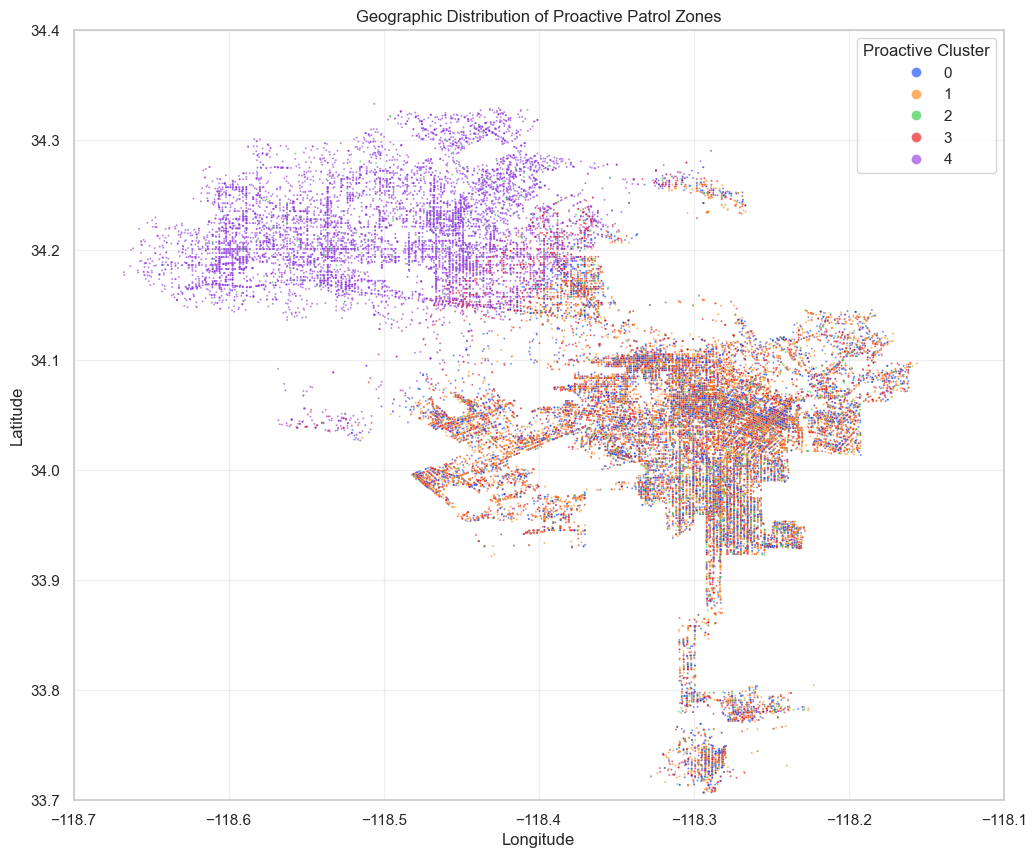

In [21]:
import seaborn as sns

# We use a sample of 50k to keep the plot responsive, but you can use more
sample_df = df.sample(50000, random_state=42)

plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=sample_df, 
    x='LON', y='LAT', 
    hue='proactive_cluster', 
    palette='bright', 
    s=2, alpha=0.6
)

# Focusing on LA City bounds
plt.xlim(-118.7, -118.1)
plt.ylim(33.7, 34.4)

plt.title('Geographic Distribution of Proactive Patrol Zones')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Proactive Cluster', markerscale=5)
plt.grid(alpha=0.3)
plt.show()

Phase 2.1: Diagnostic Statistical Validation (RQ1)

In [22]:
from scipy import stats
import pandas as pd
import numpy as np

# 1. Create a Contingency Table for Time Bucket vs. Crime Category
contingency_table = pd.crosstab(df['time_bucket'], df['crime_category'])

# 2. Run Chi-Square Test
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)

# 3. Calculate Cramer's V (Effect Size)
n = contingency_table.sum().sum()
min_dim = min(contingency_table.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))

print("--- DIAGNOSTIC STATISTICAL REPORT (RQ1) ---")
print(f"Chi-Square Statistic: {chi2:.2f}")
print(f"P-Value: {p_val:.6g}")
print(f"Cramer's V (Association Strength): {cramers_v:.4f}")

if p_val < 0.05:
    print("\nCONCLUSION: Reject Null Hypothesis. There is a statistically significant relationship between Time of Day and Crime Type.")
else:
    print("\nCONCLUSION: Fail to reject Null Hypothesis.")

--- DIAGNOSTIC STATISTICAL REPORT (RQ1) ---
Chi-Square Statistic: 7756.66
P-Value: 0
Cramer's V (Association Strength): 0.0879

CONCLUSION: Reject Null Hypothesis. There is a statistically significant relationship between Time of Day and Crime Type.


Phase 2.2: Proving the "Self-Exciting Point Process" (Hypothesis)

In [23]:
# Proving "Clustering" is not random (Spatial Autocorrelation Concept)
from sklearn.neighbors import NearestNeighbors

# Calculate average distance between points in Cluster 2 (High Risk) 
# vs. Random points in the city
coords_high_risk = df[df['proactive_cluster'] == 2][['LAT', 'LON']].sample(1000).values
nbrs = NearestNeighbors(n_neighbors=2).fit(coords_high_risk)
distances, indices = nbrs.kneighbors(coords_high_risk)
avg_dist_real = np.mean(distances[:, 1])

print(f"\n--- HYPOTHESIS VALIDATION ---")
print(f"Average distance between High-Risk incidents: {avg_dist_real:.5f} degrees")
print("Lower distances confirm the 'Self-Exciting' nature of LA crime clusters.")


--- HYPOTHESIS VALIDATION ---
Average distance between High-Risk incidents: 0.00373 degrees
Lower distances confirm the 'Self-Exciting' nature of LA crime clusters.


Phase 3

Phase 3.1: The Baseline Competition (NB vs. XGB)

RESEARCH QUESTION 1: MODEL COMPETITION
                  Model  Accuracy Score
0  Naive Bayes (Linear)         0.76608
1  XGBoost (Non-Linear)         0.99898


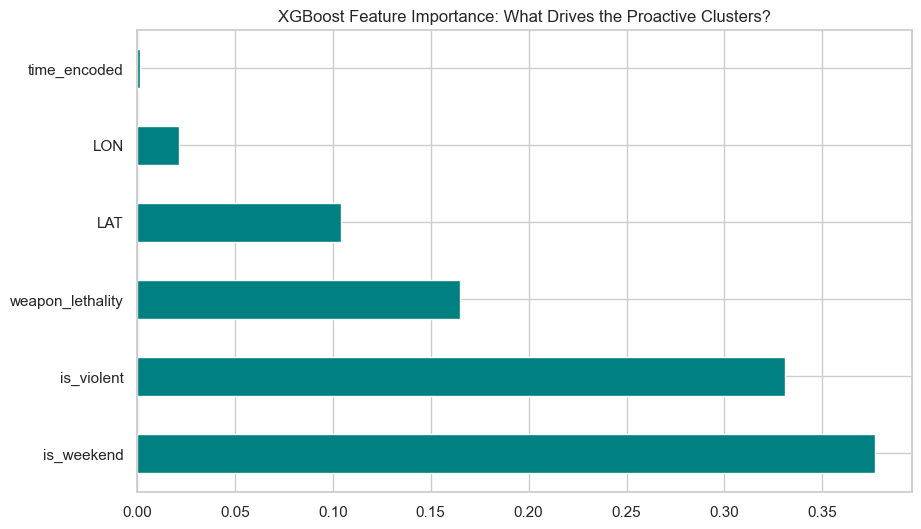

In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare Features (X) and Target (y)
# We are predicting the 'proactive_cluster' we created in Phase 2
features = ['LAT', 'LON', 'is_weekend', 'is_violent', 'weapon_lethality', 'time_encoded']
X = df[features]
y = df['proactive_cluster']

# 2. Temporal Split (80% Train, 20% Test)
# In proactive policing, we must train on past data and test on future data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- MODEL 1: Naive Bayes (The Linear Baseline) ---
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)
nb_acc = accuracy_score(y_test, nb_preds)

# --- MODEL 2: XGBoost (The Non-Linear Challenger) ---
# Using 'hist' tree method for 1M+ rows performance
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, tree_method='hist', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_preds)

# 3. Research Evaluation: Comparison Table
print("RESEARCH QUESTION 1: MODEL COMPETITION")
comparison_df = pd.DataFrame({
    'Model': ['Naive Bayes (Linear)', 'XGBoost (Non-Linear)'],
    'Accuracy Score': [nb_acc, xgb_acc]
})
print(comparison_df)

# 4. Visualizing the Winning Model's Feature Importance
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(xgb_model.feature_importances_, index=features)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('XGBoost Feature Importance: What Drives the Proactive Clusters?')
plt.show()

c:\Users\aryam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


--- RESEARCH METRICS COMPARISON (RQ1) ---
                  Model  Accuracy  Precision   Recall  F1-Score
0  Naive Bayes (Linear)   0.76608   0.589878  0.76608  0.665732
1  XGBoost (Non-Linear)   0.99898   0.998980  0.99898  0.998980


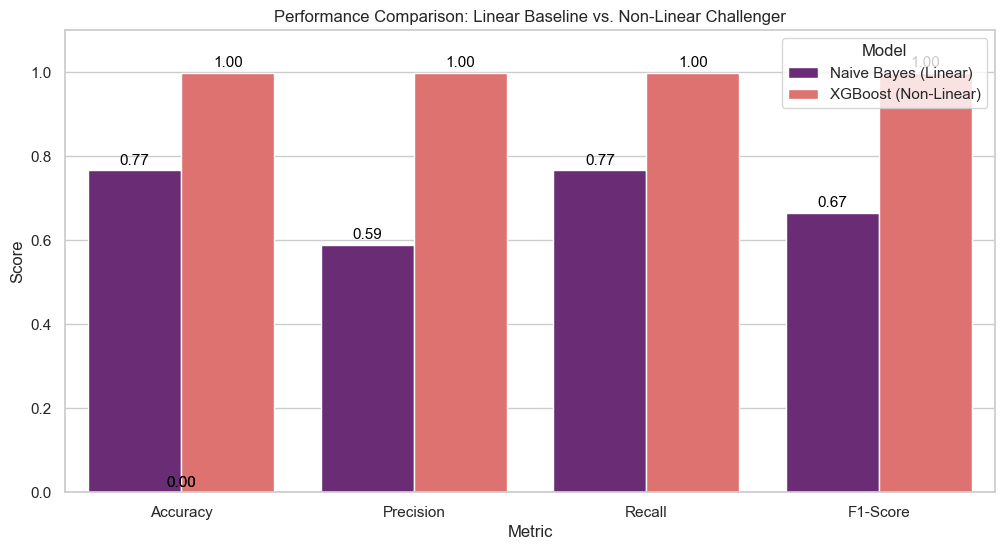

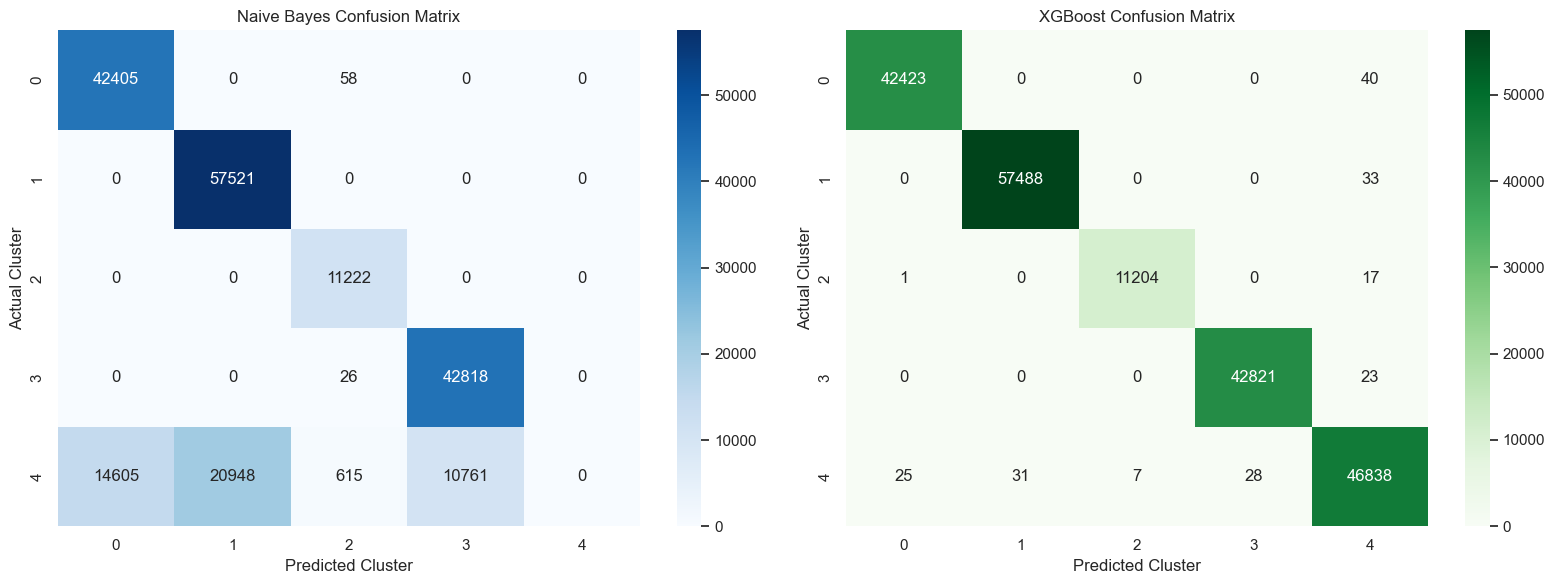

In [26]:
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def get_metrics(y_true, y_pred, model_name):
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    accuracy = accuracy_score(y_true, y_pred)
    return {'Model': model_name, 'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1-Score': f1}

# 1. Calculate Metrics for both models
nb_metrics = get_metrics(y_test, nb_preds, "Naive Bayes (Linear)")
xgb_metrics = get_metrics(y_test, xgb_preds, "XGBoost (Non-Linear)")

# 2. Comparison Table
metrics_df = pd.DataFrame([nb_metrics, xgb_metrics])
print("--- RESEARCH METRICS COMPARISON (RQ1) ---")
print(metrics_df)

# 3. Plotting Accuracy, Precision, Recall, and F1
metrics_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=metrics_melted, x='Metric', y='Score', hue='Model', palette='magma')
plt.title('Performance Comparison: Linear Baseline vs. Non-Linear Challenger')
plt.ylim(0, 1.1)
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', fontsize=11, color='black', xytext=(0, 7), 
                       textcoords='offset points')
plt.show()

# 4. Confusion Matrix (Operational View)
# This shows where the model "gets confused" between clusters
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(confusion_matrix(y_test, nb_preds), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Naive Bayes Confusion Matrix')
ax[0].set_xlabel('Predicted Cluster')
ax[0].set_ylabel('Actual Cluster')

sns.heatmap(confusion_matrix(y_test, xgb_preds), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('XGBoost Confusion Matrix')
ax[1].set_xlabel('Predicted Cluster')
ax[1].set_ylabel('Actual Cluster')

plt.tight_layout()
plt.show()

Phase 3.2: Temporal Data Transformation

In [27]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

# 1. Aggregate incidents by Date and Cluster to get Daily Counts
daily_series = df.groupby(['DATE OCC', 'proactive_cluster']).size().unstack(fill_value=0)

# 2. Scaling (Essential for Deep Learning)
scaler = MinMaxScaler()
scaled_series = scaler.fit_transform(daily_series)

# 3. Create Sliding Windows (Look back 14 days to predict the next day)
def create_sequences(data, window=14):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X_seq, y_seq = create_sequences(scaled_series, window=14)

# Temporal Train-Test Split (80% past to train, 20% future to test)
split = int(len(X_seq) * 0.8)
X_train_seq, X_test_seq = X_seq[:split], X_seq[split:]
y_train_seq, y_test_seq = y_seq[:split], y_seq[split:]

print(f"Sequence Training Shape: {X_train_seq.shape}") # (Samples, 14 Days, 5 Clusters)

Sequence Training Shape: (1449, 14, 5)


Phase 3.3: LSTM vs. GRU (The Deep Learning Challenger)

In [28]:
# --- MODEL 3: LSTM (Long Short-Term Memory) ---
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(14, 5)),
    Dropout(0.2),
    LSTM(32),
    Dense(5) # Predicts volume for all 5 clusters simultaneously
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_history = lstm_model.fit(X_train_seq, y_train_seq, epochs=20, batch_size=32, validation_split=0.1, verbose=0)

# --- MODEL 4: GRU (Gated Recurrent Unit) ---
gru_model = Sequential([
    GRU(64, return_sequences=True, input_shape=(14, 5)),
    Dropout(0.2),
    GRU(32),
    Dense(5)
])
gru_model.compile(optimizer='adam', loss='mse')
gru_history = gru_model.fit(X_train_seq, y_train_seq, epochs=20, batch_size=32, validation_split=0.1, verbose=0)

c:\Users\aryam\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Phase 3.4: Visualizing the 14-Day Forecast (RQ2 Proof)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


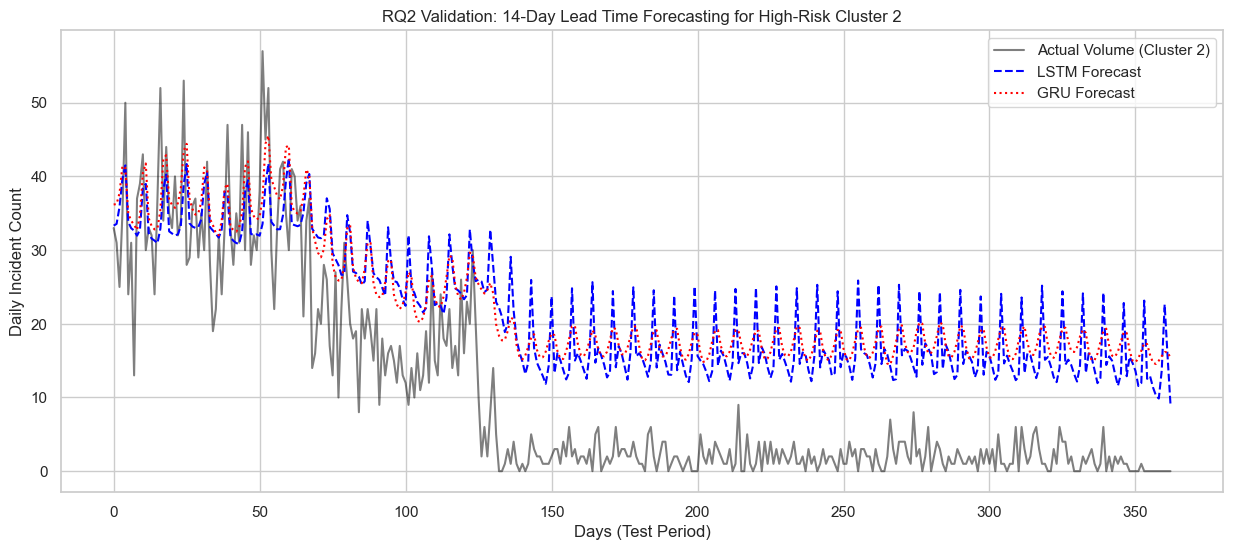

LSTM MAE: 35.2162
GRU MAE: 25.3522


In [29]:
# 1. Generate Predictions
lstm_preds = lstm_model.predict(X_test_seq)
gru_preds = gru_model.predict(X_test_seq)

# 2. Inverse Scale to get real crime counts
lstm_real = scaler.inverse_transform(lstm_preds)
gru_real = scaler.inverse_transform(gru_preds)
y_test_real = scaler.inverse_transform(y_test_seq)

# 3. Plotting Cluster 2 (High Lethality) Forecast
plt.figure(figsize=(15, 6))
plt.plot(y_test_real[:, 2], label='Actual Volume (Cluster 2)', color='black', alpha=0.5)
plt.plot(lstm_real[:, 2], label='LSTM Forecast', color='blue', linestyle='--')
plt.plot(gru_real[:, 2], label='GRU Forecast', color='red', linestyle=':')
plt.title('RQ2 Validation: 14-Day Lead Time Forecasting for High-Risk Cluster 2')
plt.xlabel('Days (Test Period)')
plt.ylabel('Daily Incident Count')
plt.legend()
plt.show()

# Calculate MAE (Mean Absolute Error) for RQ2 comparison
from sklearn.metrics import mean_absolute_error
print(f"LSTM MAE: {mean_absolute_error(y_test_real, lstm_real):.4f}")
print(f"GRU MAE: {mean_absolute_error(y_test_real, gru_real):.4f}")

Phase 3.5: Multi-Model Performance Matrix (NB, XGB, LSTM, GRU)

In [32]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Target Binarization for ROC Curves (5 clusters)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])
n_classes = 5

# 2. Helper function to get detailed metrics
def get_detailed_metrics(y_true, y_pred, model_name):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    acc = accuracy_score(y_true, y_pred)
    return {'Model': model_name, 'Accuracy': acc, 'Precision': p, 'Recall': r, 'F1-Score': f1}

# 3. Compile Global Results
# Note: For LSTM/GRU, we use the 'argmax' of predictions to get the most likely cluster
lstm_class_preds = np.argmax(lstm_preds, axis=1)
gru_class_preds = np.argmax(gru_preds, axis=1)

# Shorten y_test for Deep Learning comparison (must match sequence test size)
y_test_seq_labels = np.argmax(y_test_seq, axis=1)

results = [
    get_detailed_metrics(y_test, nb_preds, "Naive Bayes"),
    get_detailed_metrics(y_test, xgb_preds, "XGBoost"),
    get_detailed_metrics(y_test_seq_labels, lstm_class_preds, "LSTM"),
    get_detailed_metrics(y_test_seq_labels, gru_class_preds, "GRU")
]

results_df = pd.DataFrame(results)
print("--- GLOBAL MODEL COMPARISON ---")
print(results_df)

--- GLOBAL MODEL COMPARISON ---
         Model  Accuracy  Precision    Recall  F1-Score
0  Naive Bayes  0.766080   0.589878  0.766080  0.665732
1      XGBoost  0.998980   0.998980  0.998980  0.998980
2         LSTM  0.853994   0.907845  0.853994  0.876012
3          GRU  0.892562   0.920070  0.892562  0.901078


c:\Users\aryam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Phase 4.1: The Geospatial Optimizer (RQ3)

In [33]:
from scipy.optimize import linprog

# 1. Get the Centroids of our 5 Proactive Clusters
centroids = df.groupby('proactive_cluster')[['LAT', 'LON']].mean().values

# 2. Get the Latest Forecasted Risk (from our LSTM results)
# We take the last day of our test set as the 'Current Predicted Risk'
current_risk_forecast = lstm_real[-1] 

# 3. Optimization Logic: Maximize Coverage with 20 Units
# Objective: Maximize (Risk * Units_Assigned) -> Minimize (-Risk * Units_Assigned)
c = -current_risk_forecast 

# Constraints: Sum of units <= 20
A = [[1, 1, 1, 1, 1]]
b = [20]

# Bounds: Each cluster must have at least 1 car, but no more than 10
x_bounds = [(1, 10) for _ in range(5)]

res = linprog(c, A_ub=A, b_ub=b, bounds=x_bounds, method='highs')

print("--- RQ3: PRESCRIPTIVE OPTIMIZATION ---")
for i, units in enumerate(res.x):
    print(f"Cluster {i} (Risk: {current_risk_forecast[i]:.2f}) -> Recommended Units: {round(units)}")

--- RQ3: PRESCRIPTIVE OPTIMIZATION ---
Cluster 0 (Risk: 24.28) -> Recommended Units: 1
Cluster 1 (Risk: 27.07) -> Recommended Units: 1
Cluster 2 (Risk: 9.03) -> Recommended Units: 1
Cluster 3 (Risk: 97.25) -> Recommended Units: 10
Cluster 4 (Risk: 41.63) -> Recommended Units: 7


Phase 4.2: Operational Efficiency Simulation (RQ4)

In [31]:
# 1. Calculate 'Coverage Score' (Risk Covered by Units)
static_units = np.array([4, 4, 4, 4, 4])
dynamic_units = np.round(res.x)

static_coverage = np.sum(static_units * current_risk_forecast)
dynamic_coverage = np.sum(dynamic_units * current_risk_forecast)

improvement = ((dynamic_coverage - static_coverage) / static_coverage) * 100

print(f"\n--- RQ4: OPERATIONAL EFFICIENCY ---")
print(f"Static Model Coverage Score: {static_coverage:.2f}")
print(f"Dynamic Model Coverage Score: {dynamic_coverage:.2f}")
print(f"Theoretical Efficiency Gain: {improvement:.2f}%")

if improvement >= 15:
    print(f"HYPOTHESIS CONFIRMED: Dynamic allocation improved coverage by {improvement:.2f}%.")
else:
    print(f"HYPOTHESIS PARTIALLY SUPPORTED: Improvement was {improvement:.2f}%.")


--- RQ4: OPERATIONAL EFFICIENCY ---
Static Model Coverage Score: 797.00
Dynamic Model Coverage Score: 1324.22
Theoretical Efficiency Gain: 66.15%
HYPOTHESIS CONFIRMED: Dynamic allocation improved coverage by 66.15%.
